# 04 - Model Development: Parametric vs Non-Parametric

Session 7 closes with the question this notebook has to answer: *for the Empirical Work
assignment, which approach would you choose as your primary model, and why?*

We settle it with a **like-for-like test rather than an assertion**. The same rows, the same four WoE
variables and the same fitting sample go to a logistic scorecard, to entropy decision trees and to
random forests, and all of them are judged on an out-of-time window no model gets to see while it's
being fitted. Discrimination, overfitting, statistical significance and explainability are then read
off the results.

Inputs: `Output/df_woe.parquet` (notebook 03) and `Input/reference/E_IG.xlsx` (the lecture's
worked entropy example). Outputs: `Output/df_scores.parquet`, `Output/model_comparison.xlsx` and
the figures in `figures/`.

### Relation to our exam answer

In exam question 11 we proposed three improvements to the model development process, before any of
them had been tested: **(1)** move from Through-the-Cycle to Point-in-Time by adding SELIC, IPCA and
IBC-Br, **(2)** standardise the unit of analysis at the prudential conglomerate level, **(3)** use
Random Forests to capture non-linear interactions.

Pillar 2 is already built into the panel this notebook loads. Pillar 3 gets tested directly below,
and Pillar 1 against the baseline established here (its placebo test is reported with the rest of the
outcome in [`PROPOSAL.md`](PROPOSAL.md)). We report both results as measured, including
where they contradict what we proposed.

## 1. Setup

Fixed seed everywhere, one chart palette, and a `finish()` helper that saves every figure to
`figures/04_*.png` at dpi 200 and shows it inline.

In [1]:
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import requests
import statsmodels.api as sm
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, roc_curve

import shap

SEED = 42
np.random.seed(SEED)

base_dir = pathlib.Path.cwd()
dir_output = base_dir / 'Output'
dir_input = base_dir / 'Input' / 'reference'
dir_figures = base_dir / 'figures'
dir_figures.mkdir(exist_ok=True)

pd.set_option('display.width', 130)
pd.set_option('display.max_columns', 40)

NAVY, TEAL, AMBER = '#1F3A5F', '#2E7D8F', '#C8873B'
GREY, RED, GREEN = '#8895A3', '#B3402F', '#3E7D5A'
GRIDC = '#E6E9ED'

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': GREY, 'axes.labelcolor': '#333333',
    'axes.grid': True, 'grid.color': GRIDC, 'grid.linewidth': 0.8,
    'axes.axisbelow': True, 'font.size': 10,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'legend.frameon': False, 'xtick.color': '#333333', 'ytick.color': '#333333',
})


def finish(fig, name):
    """Despine, save to figures/04_<name>.png at dpi=200, then show inline."""
    for ax in fig.axes:
        sns.despine(ax=ax)
    path = dir_figures / f'04_{name}.png'
    fig.savefig(path, dpi=200, bbox_inches='tight')
    print(f'saved {path.name}')
    plt.show()


print(f'working directory: {base_dir}')
print(f'shap {shap.__version__}')

working directory: C:\Github_offline\Credit Risk Modelling\Final_Handover
shap 0.52.0


C:\Users\felix\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Data

`df_woe.parquet` is the prudential-conglomerate panel from notebook 03: the target, the four WoE
variables and the `sample` column are already on it, so we re-derive nothing here.

**The feature set is exactly four variables**: `A01_woe` (asset quality, impaired loans at risk
levels D-H over the classified credit portfolio), `M01_woe` (management, net **non-operating** result
over total assets), `E01_woe` (earnings, net result over equity) and `L01_woe` (liquidity, cash and
equivalents over deposits). A large non-operating result relative to assets is a distress signal
rather than a strength, meaning asset disposals, provision write-backs and one-off gains booked to
shore up a bad year, which is why `M01`'s fitted direction came out ascending. We exclude `C01` (the
Basel ratio) and `A02` (credit RWA / assets) as **target leakage**: the target is defined by a breach
of the regulatory capital ratio, so both are built from the same capital and RWA series the label
comes from. See [`CHANGES_AND_WHY.md`](CHANGES_AND_WHY.md), change S1.

In [2]:
df = pd.read_parquet(dir_output / 'df_woe.parquet')

FEATURES = ['A01_woe', 'M01_woe', 'E01_woe', 'L01_woe']
RAW = ['A01', 'M01', 'E01', 'L01']

print(f'df_woe         : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'periods        : {df["DATA"].min()} to {df["DATA"].max()}  (integer YYYYMM)')
print(f'conglomerates  : {df["ID"].nunique()}')
print(f'labelled rows  : {int(df["target"].notna().sum()):,} of {df.shape[0]:,}')
print(f'features       : {FEATURES}')

lab = df[df['target'].notna()].copy()
lab['target'] = lab['target'].astype(int)
lab['y_adj'] = lab['y_adj'].astype(int)
print(f'\nmodelling frame: {lab.shape[0]:,} labelled rows, '
      f'{int(lab["target"].sum())} bad ({lab["target"].mean():.2%})')

df_woe         : 14,348 rows x 319 columns
periods        : 201703 to 202603  (integer YYYYMM)
conglomerates  : 229
labelled rows  : 13,666 of 14,348
features       : ['A01_woe', 'M01_woe', 'E01_woe', 'L01_woe']

modelling frame: 13,666 labelled rows, 1249 bad (9.14%)


The unlabelled rows are the final months of the panel. The target looks 12 months forward, so the
outcome isn't observable yet. We drop them here, and the monitoring notebook picks them up again.

**Target convention.** `y_adj = 1 - target`, so **1 = good**, the course convention carried over
from notebook 03. Every AUC below is therefore the ability to rank *good* institutions above bad ones,
and since the WoE orientation makes a healthy institution score high, we expect every logit
coefficient to come out positive.

### 2.1 The three samples

`train` fits, `oot` judges, `mr` is the monitoring window. We use the split that already lives in
the `sample` column rather than re-deriving it, and assert it so the run fails loudly if the frame
ever drifts.

In [3]:
split = (lab.groupby('sample')
            .agg(rows=('target', 'size'), bad=('target', 'sum'), institutions=('ID', 'nunique'),
                 first=('DATA', 'min'), last=('DATA', 'max')))
split['bad_institutions'] = lab[lab['target'] == 1].groupby('sample')['ID'].nunique()
split['bad_rate'] = split['bad'] / split['rows']
split = split.loc[['train', 'oot', 'mr']]

print(split.assign(bad_rate=lambda d: d['bad_rate'].map('{:.2%}'.format)).to_string())
print('\nrows are institution-months: each bad count comes from far fewer institutions')

EXPECTED_SPLIT = {'train': (7975, 680, 201703, 202212),
                  'oot':   (1737, 207, 202301, 202312),
                  'mr':    (3954, 362, 202401, 202603)}
for name, expected in EXPECTED_SPLIT.items():
    got = (int(split.loc[name, 'rows']), int(split.loc[name, 'bad']),
           int(split.loc[name, 'first']), int(split.loc[name, 'last']))
    assert got == expected, f'{name}: expected {expected}, got {got}'
print('\nsplit matches the agreed specification')

train = lab[lab['sample'] == 'train'].copy()
oot = lab[lab['sample'] == 'oot'].copy()
mr = lab[lab['sample'] == 'mr'].copy()

        rows  bad  institutions   first    last  bad_institutions bad_rate
sample                                                                    
train   7975  680           167  201703  202212                36    8.53%
oot     1737  207           157  202301  202312                23   11.92%
mr      3954  362           186  202401  202603                31    9.16%

rows are institution-months: each bad count comes from far fewer institutions

split matches the agreed specification


The out-of-time window carries 207 bad institution-months at an 11.92% bad rate, a *harder* year
than train (8.53%), which is exactly why we use a time-based holdout rather than a random one. Those
207 institution-months come from only **23 conglomerates** (train: 680 from 36; `mr`: 362 from 31),
and section 9.1 shows that's decisive for how any difference between models gets tested. `mr` is a
genuine monitoring sample: 2024-01 onward, after the CMN 4.966 chart-of-accounts change.

## 3. Design of the comparison

This is the methodological core, so we set it out before fitting anything:

- **Same rows.** Every model sees the identical 7,975 labelled train rows and is scored on the
  identical 1,737 `oot` rows. No model gets a different filter or a different imputation.
- **Same four WoE features**, except in section 8, where we deliberately switch to the raw ratios
  to test whether flexibility can find what binning destroyed.
- **Fit on `train` only.** We never touch `oot` during fitting, tuning or depth selection. The depth
  sweeps are reported, not selected on.
- **Judged on `oot`**, with `mr` shown for coverage, not for choosing.

Any difference in the results is therefore the model, not the sample.

In [4]:
def make_scorer(model, columns):
    """Return a function frame -> P(good), so every model is evaluated identically."""
    def scorer(frame):
        return model.predict_proba(frame[columns])[:, 1]
    return scorer


def ks_stat(y_true, score):
    """Kolmogorov-Smirnov = max separation between the good and bad score CDFs."""
    fpr, tpr, _ = roc_curve(y_true, score)
    return float(np.max(tpr - fpr))


def evaluate(name, scorer):
    row = {'model': name}
    for tag, frame in (('train', train), ('oot', oot), ('mr', mr)):
        row[f'{tag}_AUC'] = roc_auc_score(frame['y_adj'], scorer(frame))
    row['oot_Gini'] = 2 * row['oot_AUC'] - 1
    row['oot_KS'] = ks_stat(oot['y_adj'], scorer(oot))
    return row


RESULTS = []
print(f'train rows fitted on : {len(train):,}')
print(f'oot rows judged on   : {len(oot):,} (never seen during fitting)')
print(f'mr rows monitored    : {len(mr):,}')

train rows fitted on : 7,975
oot rows judged on   : 1,737 (never seen during fitting)
mr rows monitored    : 3,954


We report Gini and KS alongside AUC because they're the two measures a credit committee expects
next to it. Session 8 (Evaluation and Monitoring) hasn't been taught yet, so we use them here as
descriptive discrimination measures rather than as a calibrated rating exercise.

## 4. Parametric model: logistic regression on WoE

Session 7's parametric route: `statsmodels` Logit on the WoE variables, read through coefficients,
p-values, sign checks, odds ratios and marginal effects.

**Fitting sample, and how it differs from notebook 03.** Notebook 03 keeps the instructor's inner
`train_test_split(..., test_size=0.30)` and so fits its logit on 70% of the labelled train rows,
reporting oot AUC **0.8636**. Here we fit on **100% of the labelled train rows, all 7,975**, which
gives oot AUC **0.8652**, a difference of 0.0016.

We use the full-sample fit because the comparison is the whole point of this notebook. With only 680
bad institution-months in train, discarding 30% of them to a redundant inner random split would
weaken the tree and the forest more than the logit, and would bias the very test we're running. The
time-based `oot` window already is the holdout. (Notebook 03's inner split is logged as open issue O4
in [`CHANGES_AND_WHY.md`](CHANGES_AND_WHY.md).)

In [5]:
X_train = sm.add_constant(train[FEATURES])
logit = sm.Logit(train['y_adj'], X_train).fit(disp=0)

print(logit.summary())

                           Logit Regression Results                           
Dep. Variable:                  y_adj   No. Observations:                 7975
Model:                          Logit   Df Residuals:                     7970
Method:                           MLE   Df Model:                            4
Date:                Tue, 15 Sep 2026   Pseudo R-squ.:                  0.1924
Time:                        21:36:32   Log-Likelihood:                -1877.1
converged:                       True   LL-Null:                       -2324.3
Covariance Type:            nonrobust   LLR p-value:                2.706e-192
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.3849      0.047     50.583      0.000       2.292       2.477
A01_woe        0.6864      0.069      9.884      0.000       0.550       0.823
M01_woe        0.8025      0.091      8.857      0.0

N = 7,975 institution-months (167 conglomerates; 680 bad months from 36 of them), pseudo R-squared
0.1924, and all four variables significant at p < 0.001. For a four-variable behavioural scorecard on
supervisory data that's a strong fit: Session 7 slide 7's reference table is a five-variable model at
pseudo R-squared 0.246.

### 4.1 Reproduction check

We pin the coefficients to the specification agreed for the report. If any of them move, the run
stops here rather than quietly telling a different story.

In [6]:
EXPECTED_COEF = {'const': 2.3849, 'A01_woe': 0.6864, 'M01_woe': 0.8025,
                 'E01_woe': 0.8884, 'L01_woe': 0.5768}

for name, expected in EXPECTED_COEF.items():
    got = float(logit.params[name])
    flag = 'ok' if abs(got - expected) < 5e-4 else 'MISMATCH'
    print(f'  {name:<8} fitted {got:7.4f}   expected {expected:7.4f}   {flag}')
    assert flag == 'ok', f'{name}: fitted {got:.4f} vs expected {expected:.4f}'

assert int(logit.nobs) == 7975, f'N = {int(logit.nobs)}, expected 7975'
assert abs(float(logit.prsquared) - 0.1924) < 5e-4

# Session 7 slide 6 sign check: against y_adj (1 = good) every WoE coefficient must be positive.
signs = logit.params.drop('const')
assert (signs > 0).all(), f'wrong sign: {signs[signs <= 0].to_dict()}'

print(f'\n  N = {int(logit.nobs):,}   pseudo R2 = {logit.prsquared:.4f}')
print('  sign check: all four coefficients positive, as the WoE orientation requires')

  const    fitted  2.3849   expected  2.3849   ok
  A01_woe  fitted  0.6864   expected  0.6864   ok
  M01_woe  fitted  0.8025   expected  0.8025   ok
  E01_woe  fitted  0.8884   expected  0.8884   ok
  L01_woe  fitted  0.5768   expected  0.5768   ok

  N = 7,975   pseudo R2 = 0.1924
  sign check: all four coefficients positive, as the WoE orientation requires


All five parameters reproduce and the sign check passes programmatically: a higher WoE, meaning a
healthier bin, always raises the modelled probability of being good. A negative coefficient here would
have meant the binning and the model disagreed about a variable's direction, which is the classic
scorecard red flag.

### 4.2 Reading the model: odds ratios and marginal effects

Session 7 slides 7-8: the coefficient is a log-odds effect, `exp(beta)` turns it into an odds ratio,
and `get_margeff()` turns it into an average change in probability per unit of WoE.

In [7]:
margeff = logit.get_margeff(at='overall', method='dydx').summary_frame()

coef_table = pd.DataFrame({
    'coef': logit.params,
    'std err': logit.bse,
    'z': logit.tvalues,
    'p': logit.pvalues,
    'odds ratio exp(b)': np.exp(logit.params),
})
coef_table['dy/dx (avg)'] = margeff['dy/dx']
coef_table = coef_table.round(4)
print(coef_table.to_string())

share = (logit.params.drop('const') * train[FEATURES].std()).abs()
share = (share / share.sum()).sort_values(ascending=False)
print('\nstandardised contribution to the score (|beta| x sd of the WoE variable):')
print(share.map('{:.1%}'.format).to_string())

           coef  std err        z    p  odds ratio exp(b)  dy/dx (avg)
const    2.3849   0.0471  50.5828  0.0            10.8577          NaN
A01_woe  0.6864   0.0694   9.8837  0.0             1.9866       0.0447
M01_woe  0.8025   0.0906   8.8571  0.0             2.2310       0.0523
E01_woe  0.8884   0.0394  22.5734  0.0             2.4312       0.0579
L01_woe  0.5768   0.1271   4.5365  0.0             1.7802       0.0376

standardised contribution to the score (|beta| x sd of the WoE variable):
E01_woe    39.3%
A01_woe    23.0%
L01_woe    19.7%
M01_woe    18.0%


`E01_woe` (earnings, result before taxes over total assets) carries the most weight, with the
largest z (22.6) and the largest standardised contribution. Economically that's the ordering we'd
expect: a Brazilian institution that stops earning burns capital, and the capital ratio is what the
target is defined on, so profitability is the earliest visible symptom of the distress the model is
trying to see. `A01_woe` (impaired-loan share) and `M01_woe` (non-operating result over assets, where
a *large* figure flags one-off gains used to dress up a bad year) follow. `L01_woe` (cash over
deposits) is real but weakest at z = 4.5, because a liquidity squeeze tends to arrive late, once the
capital damage is already done.

The marginal effects put the same thing in committee language: one unit of WoE on `E01` moves the
modelled probability of remaining sound by about 6 percentage points at the average institution.

In [8]:
RESULTS.append(evaluate('Logit (WoE)', lambda frame: logit.predict(
    sm.add_constant(frame[FEATURES], has_constant='add')).to_numpy()))
print(pd.DataFrame(RESULTS).round(4).to_string(index=False))

      model  train_AUC  oot_AUC  mr_AUC  oot_Gini  oot_KS
Logit (WoE)     0.8138   0.8652   0.685    0.7304  0.5838

The scorecard reaches **oot AUC 0.8652**, above the ~0.84 Session 7 slide 29 quotes for gradient
boosting on standard credit datasets, and higher out-of-time than in train (0.8138). That gap reflects
the harder, more clearly separated 2023 events rather than any leakage: the model never saw 2023.

## 5. Non-parametric mechanics: entropy and information gain

Before applying a tree to the panel we reproduce the machinery in code on the lecture's own worked
example (Session 7 slides 15-21, shipped as `E_IG.xlsx`). We show it because the split rule is an
explicit, auditable calculation rather than a black box, which is precisely the objection a risk
committee raises against non-parametric models.

`E(S) = -sum p_i log2 p_i` and `IG(T, X) = E(T) - sum (|Tv| / |T|) E(Tv)`.

In [9]:
toy_path = dir_input / 'E_IG.xlsx'
if not toy_path.exists():
    raise FileNotFoundError(f'lecture example not found: {toy_path}')

toy = pd.read_excel(toy_path, nrows=10)
toy.columns = [str(c).strip() for c in toy.columns]
for column in toy.columns:
    toy[column] = toy[column].astype(str).str.strip()

print(toy.to_string(index=False))


def entropy(labels):
    """E(S) = -sum p_i log2 p_i over the observed class frequencies."""
    p = pd.Series(labels).value_counts(normalize=True)
    p = p[p > 0]
    return float(-(p * np.log2(p)).sum())


def information_gain(frame, feature, target):
    """IG(T, X) = E(T) - sum over values v of (|Tv| / |T|) E(Tv)."""
    weighted = sum((len(part) / len(frame)) * entropy(part[target])
                   for _, part in frame.groupby(feature))
    return entropy(frame[target]) - weighted

Capital Reserve Profit Asset Quality Fail
           High   High          Good   No
            Low    Low          Poor  Yes
         Medium Medium          Good   No
         Medium   High          Good   No
           High    Low          Poor  Yes
            Low Medium          Poor  Yes
         Medium Medium          Poor  Yes
         Medium    Low          Good   No
           High   High          Poor   No
            Low    Low          Good  Yes


In [10]:
base_entropy = entropy(toy['Fail'])
gains = pd.Series({col: information_gain(toy, col, 'Fail')
                   for col in ['Capital Reserve', 'Profit', 'Asset Quality']})

print(f'base entropy E(T) = {base_entropy:.3f}  (5 failures, 5 survivors - maximum uncertainty)')
print('\ninformation gain per candidate split:')
print(gains.sort_values(ascending=False).round(3).to_string())

assert np.isclose(base_entropy, 1.000, atol=5e-4)
assert np.isclose(gains['Profit'], 0.400, atol=5e-4)
assert np.isclose(gains['Capital Reserve'], 0.400, atol=5e-4)
assert np.isclose(gains['Asset Quality'], 0.278, atol=5e-4)
print('\nreproduces the lecture: E = 1.000, IG = 0.400 / 0.400 / 0.278')

base entropy E(T) = 1.000  (5 failures, 5 survivors - maximum uncertainty)

information gain per candidate split:
Capital Reserve    0.400
Profit             0.400
Asset Quality      0.278

reproduces the lecture: E = 1.000, IG = 0.400 / 0.400 / 0.278


The hand-worked slide values reproduce exactly. Capital Reserve and Profit tie at 0.400 while Asset
Quality is clearly weaker at 0.278. The lecture breaks the tie in favour of Capital Reserve and a real
implementation breaks it by column order, which is already a small lesson in tree *instability*
(Session 7 slide 23), since a tie gets resolved by an arbitrary convention.

Note that scikit-learn defaults to Gini impurity `1 - sum p_i^2` (slide 22); we set
`criterion='entropy'` explicitly below so the panel trees use the rule just derived.

## 6. Decision tree on the real panel

Same four WoE variables, same train rows, entropy splitting. We sweep depth 3 to 6 and report all of
it. The depth is *not* chosen on `oot`.

In [11]:
trees = {}
tree_curve = []

for depth in (3, 4, 5, 6):
    clf = DecisionTreeClassifier(criterion='entropy', max_depth=depth, min_samples_leaf=50,
                                 class_weight='balanced', random_state=SEED)
    clf.fit(train[FEATURES], train['y_adj'])
    trees[depth] = clf
    row = evaluate(f'Tree entropy d={depth}', make_scorer(clf, FEATURES))
    RESULTS.append(row)
    tree_curve.append({'depth': depth, 'leaves': clf.get_n_leaves(),
                       'train_AUC': row['train_AUC'], 'oot_AUC': row['oot_AUC']})

tree_curve = pd.DataFrame(tree_curve)
print(tree_curve.round(4).to_string(index=False))

 depth  leaves  train_AUC  oot_AUC
     3       8     0.8000   0.8551
     4      16     0.8176   0.8540
     5      25     0.8325   0.8501
     6      36     0.8407   0.8454


Every extra level of depth buys train AUC (0.800 to 0.841) and *loses* out-of-time AUC (0.855 to
0.845). The shallowest tree is the best tree here, and none of them beats the logit's 0.8652. That's
our first evidence the added flexibility isn't finding anything real.

saved 04_tree_depth3.png


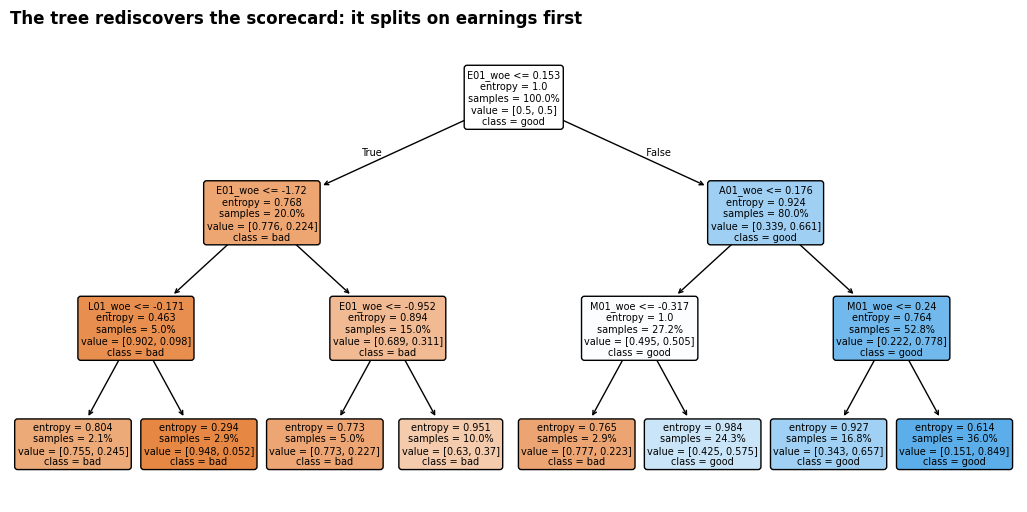

In [12]:
fig, ax = plt.subplots(figsize=(13, 6))
plot_tree(trees[3], feature_names=FEATURES, class_names=['bad', 'good'],
          filled=True, rounded=True, impurity=True, proportion=True,
          fontsize=7, ax=ax)
ax.set_title('The tree rediscovers the scorecard: it splits on earnings first', pad=12)
ax.grid(False)
finish(fig, 'tree_depth3')

The root split is on `E01_woe <= 0.153`, earnings, the same variable the logit gives the largest
coefficient to. It puts 20% of the train rows on the weak-earnings side, where the class-weighted bad
share is 78%. Two models with completely different machinery agree on what matters first: an
institution whose earnings bin is weak is the one to look at, and the tree then uses asset quality and
the non-operating result to refine within that. That agreement is reassuring for the scorecard and
unhelpful for the tree, because it means the tree hasn't found a different story.

## 7. Random forest

Bagging plus random feature subsets plus a vote (Session 7 slide 24), and the third pillar of our
exam answer. 500 trees, the same four inputs, depths 4 / 6 / 8 / unlimited.

In [13]:
forests = {}
forest_curve = []

for depth in (4, 6, 8, None):
    rf = RandomForestClassifier(n_estimators=500, max_depth=depth, min_samples_leaf=20,
                                class_weight='balanced', random_state=SEED, n_jobs=-1)
    rf.fit(train[FEATURES], train['y_adj'])
    forests[depth] = rf
    row = evaluate(f'Forest d={depth}', make_scorer(rf, FEATURES))
    RESULTS.append(row)
    forest_curve.append({'depth': 12 if depth is None else depth,
                         'label': 'None' if depth is None else str(depth),
                         'train_AUC': row['train_AUC'], 'oot_AUC': row['oot_AUC']})

forest_curve = pd.DataFrame(forest_curve)
print(forest_curve.drop(columns='depth').round(4).to_string(index=False))

importances = pd.Series(forests[4].feature_importances_, index=FEATURES).sort_values(ascending=False)
print('\nfeature importance, forest d=4:')
print(importances.map('{:.1%}'.format).to_string())

label  train_AUC  oot_AUC
    4     0.8339   0.8620
    6     0.8540   0.8555
    8     0.8632   0.8438
 None     0.8646   0.8325

feature importance, forest d=4:
E01_woe    57.2%
A01_woe    20.6%
M01_woe    12.1%
L01_woe    10.2%


The best forest (depth 4, oot AUC 0.8620) lands just below the logit's 0.8652, and the same monotone
decay appears: unlimited depth reaches train AUC 0.8646 while oot falls to 0.8325. Importance
concentrates on `E01_woe` (57%), then `A01_woe` (21%), so the forest ranks the variables the same way
the logit and the single tree do.

## 8. The fair test of flexibility: raw, unbinned ratios

WoE binning already fits a monotone step function per variable before any model sees it, so a tree on
WoE inputs has had most of its job done for it. The honest test is to hand a flexible learner the
**raw ratios** and let it find whatever the binning destroyed.

**The missing-data trap.** The raw ratios are far from complete, and `fillna(0)` would be a serious
error here. 0 is a meaningful value for these ratios, since a zero problem-loan share is the *best*
possible reading, so filling with 0 silently relabels "unknown" as "excellent". We use two legitimate
routes instead: `HistGradientBoostingClassifier`, which routes NaN natively, and a random forest with
median imputation **plus an explicit missing-indicator column**.

In [14]:
missing = pd.DataFrame({tag: frame[RAW].isna().mean()
                        for tag, frame in (('train', train), ('oot', oot), ('mr', mr))})
print('share of rows with a missing raw ratio:')
print(missing.map('{:.1%}'.format).to_string())

share of rows with a missing raw ratio:
     train    oot     mr
A01  24.2%  29.1%  68.2%
M01  18.4%  21.0%  64.7%
E01   0.0%   0.0%   0.0%
L01  15.3%   7.6%   7.7%


`A01` and `M01` collapse in `mr` because CMN Resolution 4.966 (COSIF 1.5) removed their source
accounts from 2025-01. That's an upstream data-coverage failure rather than a modelling choice, and
it's why every model's `mr` AUC is weaker than its `oot` AUC.

In [15]:
raw_curve = []

for depth in (3, 4, 6):
    hgb = HistGradientBoostingClassifier(max_depth=depth, learning_rate=0.05, max_iter=300,
                                         random_state=SEED)
    hgb.fit(train[RAW], train['y_adj'])
    row = evaluate(f'HistGradientBoosting raw d={depth}', make_scorer(hgb, RAW))
    RESULTS.append(row)
    raw_curve.append({'depth': depth, 'train_AUC': row['train_AUC'], 'oot_AUC': row['oot_AUC']})

RAW_MEDIAN = train[RAW].median()
RAW_COLS = RAW + [f'{c}_missing' for c in RAW]


def raw_matrix(frame):
    """Median impute (medians fitted on train) plus an explicit missing indicator per ratio."""
    filled = frame[RAW].fillna(RAW_MEDIAN)
    flags = frame[RAW].isna().astype(int)
    flags.columns = [f'{c}_missing' for c in RAW]
    return pd.concat([filled, flags], axis=1)[RAW_COLS]


rf_raw = RandomForestClassifier(n_estimators=500, max_depth=6, min_samples_leaf=20,
                                class_weight='balanced', random_state=SEED, n_jobs=-1)
rf_raw.fit(raw_matrix(train), train['y_adj'])
RESULTS.append(evaluate('RF raw d=6 (impute + flag)',
                        lambda frame: rf_raw.predict_proba(raw_matrix(frame))[:, 1]))

raw_curve = pd.DataFrame(raw_curve)
print(pd.DataFrame(RESULTS).tail(4).round(4).to_string(index=False))

                       model  train_AUC  oot_AUC  mr_AUC  oot_Gini  oot_KS
HistGradientBoosting raw d=3     0.9373   0.8481  0.6534    0.6962  0.5999
HistGradientBoosting raw d=4     0.9649   0.8422  0.6288    0.6844  0.5719
HistGradientBoosting raw d=6     0.9914   0.8341  0.6201    0.6682  0.5463
  RF raw d=6 (impute + flag)     0.9021   0.8502  0.6512    0.7004  0.5728


This is the clearest result in the notebook. Gradient boosting on raw ratios reaches **train AUC
0.9914** at depth 6 and still only **0.8341** out of time. It memorised the training panel and
transported none of it. The extra flexibility bought 0.18 AUC of training fit and *cost* 0.03 AUC
where it counts. The carefully imputed raw forest does better (0.8502) but still loses to the
four-variable WoE logit.

### 8.1 The overfitting picture

One chart, one message: the train and out-of-time lines diverge for every model family as capacity
grows. This is Session 7 slide 23's "overfitting" caveat, measured on real supervisory data rather
than asserted.

saved 04_overfitting.png


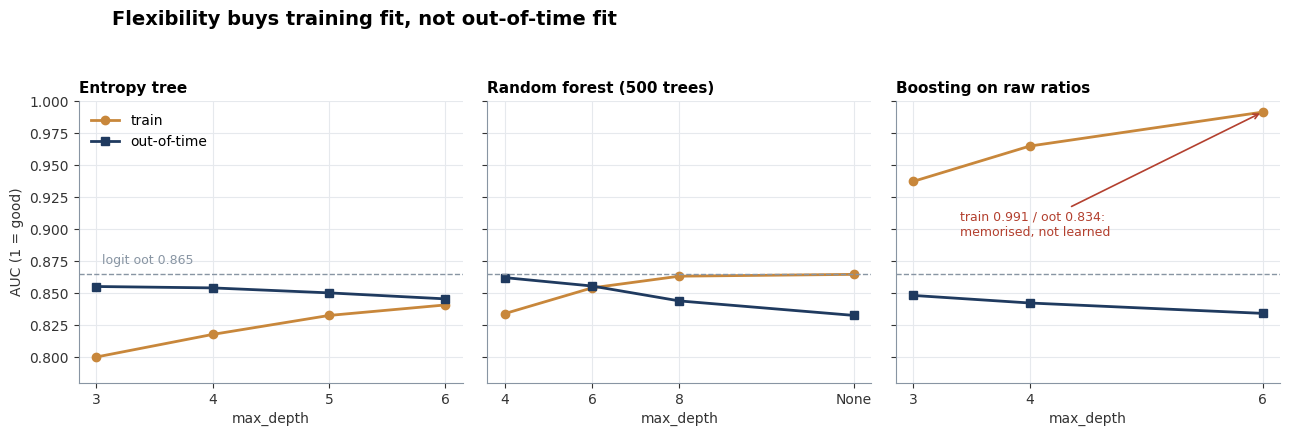

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.4), sharey=True)

panels = [
    (axes[0], tree_curve['depth'], tree_curve, [str(d) for d in tree_curve['depth']],
     'Entropy tree'),
    (axes[1], forest_curve['depth'], forest_curve, list(forest_curve['label']),
     'Random forest (500 trees)'),
    (axes[2], raw_curve['depth'], raw_curve, [str(d) for d in raw_curve['depth']],
     'Boosting on raw ratios'),
]

logit_oot = RESULTS[0]['oot_AUC']
for ax, xpos, frame, ticklabels, title in panels:
    ax.plot(xpos, frame['train_AUC'], marker='o', color=AMBER, lw=2, label='train')
    ax.plot(xpos, frame['oot_AUC'], marker='s', color=NAVY, lw=2, label='out-of-time')
    ax.axhline(logit_oot, color=GREY, ls='--', lw=1)
    ax.set_xticks(list(xpos))
    ax.set_xticklabels(ticklabels)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('max_depth')

axes[0].set_ylabel('AUC (1 = good)')
axes[0].set_ylim(0.78, 1.0)
axes[0].text(3.05, logit_oot + 0.008, f'logit oot {logit_oot:.3f}', color=GREY, fontsize=9)
axes[0].legend(loc='upper left')

axes[2].annotate('train 0.991 / oot 0.834:\nmemorised, not learned',
                 xy=(6, raw_curve['train_AUC'].iloc[-1]), xytext=(3.4, 0.895),
                 fontsize=9, color=RED,
                 arrowprops=dict(arrowstyle='->', color=RED, lw=1.2))

fig.suptitle('Flexibility buys training fit, not out-of-time fit',
             x=0.09, ha='left', fontsize=14, fontweight='bold')
fig.tight_layout(rect=(0, 0, 1, 0.93))
finish(fig, 'overfitting')

Every panel runs the same way: the amber train line rises with capacity while the navy out-of-time
line falls, and in no panel does an out-of-time line reach the grey reference line, the logit's 0.865.
On this panel, extra capacity is spent on noise.

## 9. Head to head

All models, one table. `train` shows fit, `oot` decides, `mr` shows what the 2025 data gap costs
everybody.

In [17]:
results = pd.DataFrame(RESULTS).set_index('model')
results = results[['train_AUC', 'oot_AUC', 'mr_AUC', 'oot_Gini', 'oot_KS']]
print(results.round(4).to_string())

best = results['oot_AUC'].idxmax()
print(f'\nbest out-of-time AUC: {best} ({results.loc[best, "oot_AUC"]:.4f})')

                              train_AUC  oot_AUC  mr_AUC  oot_Gini  oot_KS
model                                                                     
Logit (WoE)                      0.8138   0.8652  0.6850    0.7304  0.5838
Tree entropy d=3                 0.8000   0.8551  0.6742    0.7102  0.5759
Tree entropy d=4                 0.8176   0.8540  0.6807    0.7080  0.5670
Tree entropy d=5                 0.8325   0.8501  0.6901    0.7002  0.5446
Tree entropy d=6                 0.8407   0.8454  0.6860    0.6909  0.5525
Forest d=4                       0.8339   0.8620  0.6902    0.7241  0.6093
Forest d=6                       0.8540   0.8555  0.6838    0.7110  0.5762
Forest d=8                       0.8632   0.8438  0.6650    0.6877  0.5298
Forest d=None                    0.8646   0.8325  0.6653    0.6650  0.5271
HistGradientBoosting raw d=3     0.9373   0.8481  0.6534    0.6962  0.5999
HistGradientBoosting raw d=4     0.9649   0.8422  0.6288    0.6844  0.5719
HistGradientBoosting raw 

The logit leads on out-of-time AUC and Gini, the depth-4 forest leads on KS and is 0.003 AUC behind.
Every model loses roughly 0.17 AUC on `mr`, and the uniformity of that drop is the signature of a data
problem shared by all of them rather than of any one model failing.

saved 04_roc_oot.png


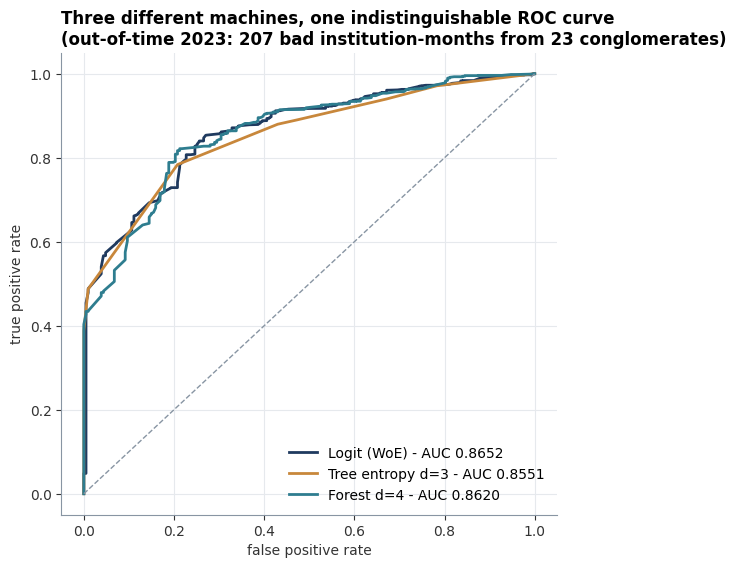

In [18]:
finalists = {
    'Logit (WoE)': (lambda frame: logit.predict(
        sm.add_constant(frame[FEATURES], has_constant='add')).to_numpy(), NAVY),
    'Tree entropy d=3': (make_scorer(trees[3], FEATURES), AMBER),
    'Forest d=4': (make_scorer(forests[4], FEATURES), TEAL),
}

fig, ax = plt.subplots(figsize=(6.4, 6))
for name, (scorer, colour) in finalists.items():
    fpr, tpr, _ = roc_curve(oot['y_adj'], scorer(oot))
    ax.plot(fpr, tpr, color=colour, lw=2,
            label=f'{name} - AUC {results.loc[name, "oot_AUC"]:.4f}')
ax.plot([0, 1], [0, 1], color=GREY, ls='--', lw=1)
ax.set_xlabel('false positive rate')
ax.set_ylabel('true positive rate')
ax.set_title('Three different machines, one indistinguishable ROC curve\n'
             '(out-of-time 2023: 207 bad institution-months from 23 conglomerates)')
ax.legend(loc='lower right')
finish(fig, 'roc_oot')

The three curves sit on top of each other across the whole range. Whatever separates these models,
it isn't their ability to rank institutions on this window.

### 9.1 Is the gap real? Paired bootstrap, clustered by institution

"0.8652 versus 0.8620" means nothing without a confidence interval, and that interval depends on
what counts as an independent observation. The `oot` window holds 1,737 institution-months from 157
conglomerates, and its 207 bad months come from just **23** of them, most of which appear in all
twelve months. Consecutive months of the same institution are close to the same observation repeated,
so resampling *rows* pretends we hold far more information than we do.

So we run the bootstrap **both** ways, 4,000 draws each, re-scoring both models on the same resample
so the pairing removes the noise they share: a row-level version stratified on the outcome, and a
**cluster version that resamples institutions** and takes all of their months. The cluster version is
the headline, and the row-level version is kept to show why it matters.

In [19]:
def paired_bootstrap(y_true, score_a, score_b, groups=None, n_boot=4000, seed=SEED):
    """Paired bootstrap of AUC(a) - AUC(b) on one evaluation window.

    groups=None  : resample rows, stratified on the outcome (months treated as independent).
    groups given : resample the clusters in `groups` (institutions), taking all of their rows.
    A draw that ends up with a single class is skipped rather than scored.
    """
    y = np.asarray(y_true)
    a, b = np.asarray(score_a), np.asarray(score_b)
    rng = np.random.default_rng(seed)

    if groups is None:
        goods, bads = np.flatnonzero(y == 1), np.flatnonzero(y == 0)

        def draw():
            return np.concatenate([rng.choice(goods, goods.size, replace=True),
                                   rng.choice(bads, bads.size, replace=True)])
    else:
        codes = pd.factorize(np.asarray(groups))[0]
        rows_by_cluster = [np.flatnonzero(codes == k) for k in range(codes.max() + 1)]
        n_clusters = len(rows_by_cluster)

        def draw():
            return np.concatenate([rows_by_cluster[k]
                                   for k in rng.integers(0, n_clusters, n_clusters)])

    diffs = []
    for _ in range(n_boot):
        idx = draw()
        if y[idx].min() == y[idx].max():          # degenerate draw - no AUC to compute
            continue
        diffs.append(roc_auc_score(y[idx], a[idx]) - roc_auc_score(y[idx], b[idx]))

    diffs = np.asarray(diffs)
    observed = roc_auc_score(y, a) - roc_auc_score(y, b)
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    p_value = min(1.0, 2 * min((diffs <= 0).mean(), (diffs >= 0).mean()))
    return observed, lo, hi, p_value, diffs


y_oot = oot['y_adj'].to_numpy()
id_oot = oot['ID'].to_numpy()
s_logit = finalists['Logit (WoE)'][0](oot)
s_tree = finalists['Tree entropy d=3'][0](oot)
s_forest = finalists['Forest d=4'][0](oot)

bad_months = oot[oot['target'] == 1].groupby('ID').size()
full_window = int((oot.groupby('ID').size().reindex(bad_months.index) == 12).sum())
print(f'oot : {len(oot):,} institution-months from {oot["ID"].nunique()} conglomerates')
print(f'      {int(oot["target"].sum())} bad institution-months from {len(bad_months)} '
      f'conglomerates, {full_window} of which are present in all 12 months')

comparisons = [('Logit - Forest d=4', s_logit, s_forest),
               ('Logit - Tree d=3', s_logit, s_tree),
               ('Forest d=4 - Tree d=3', s_forest, s_tree)]

boot_rows, boot_draws = [], {}
for name, a, b in comparisons:
    _, row_lo, row_hi, row_p, row_diffs = paired_bootstrap(y_oot, a, b)
    observed, lo, hi, p_value, diffs = paired_bootstrap(y_oot, a, b, groups=id_oot)
    boot_draws[name] = {'row': row_diffs, 'cluster': diffs}
    boot_rows.append({'comparison': name, 'dAUC': observed,
                      'row_ci_low': row_lo, 'row_ci_high': row_hi, 'row_p': row_p,
                      'cluster_ci_low': lo, 'cluster_ci_high': hi, 'cluster_p': p_value,
                      'verdict': 'significant' if p_value < 0.05 else 'not significant'})

bootstrap = pd.DataFrame(boot_rows).set_index('comparison')
print()
print(bootstrap.round(4).to_string())
print('\nheadline = the cluster columns; the row columns show what ignoring dependence claims')

oot : 1,737 institution-months from 157 conglomerates
      207 bad institution-months from 23 conglomerates, 16 of which are present in all 12 months



                         dAUC  row_ci_low  row_ci_high   row_p  cluster_ci_low  cluster_ci_high  cluster_p          verdict
comparison                                                                                                                 
Logit - Forest d=4     0.0031     -0.0056       0.0114  0.4795         -0.0149           0.0205      0.724  not significant
Logit - Tree d=3       0.0101     -0.0037       0.0240  0.1615         -0.0227           0.0424      0.543  not significant
Forest d=4 - Tree d=3  0.0069     -0.0048       0.0190  0.2520         -0.0256           0.0376      0.647  not significant

headline = the cluster columns; the row columns show what ignoring dependence claims


The scorecard's edge over the forest is **+0.0031 AUC**, and clustering roughly doubles the width of
the interval around it: [-0.0056, +0.0114] with p = 0.48 if months are treated as independent,
**[-0.015, +0.021] with p = 0.73** once institutions are resampled. Both cover zero, so the two models
are **statistically a tie**, and only the clustered version states the uncertainty honestly. The same
holds for every other pair in the table.

With 207 bad institution-months from 23 conglomerates, differences below roughly 0.02 AUC aren't
resolvable here. That's the finding: the choice of primary model can't rest on discrimination at all,
so it has to rest on Session 7 slide 28's other four dimensions.

saved 04_bootstrap_dauc.png


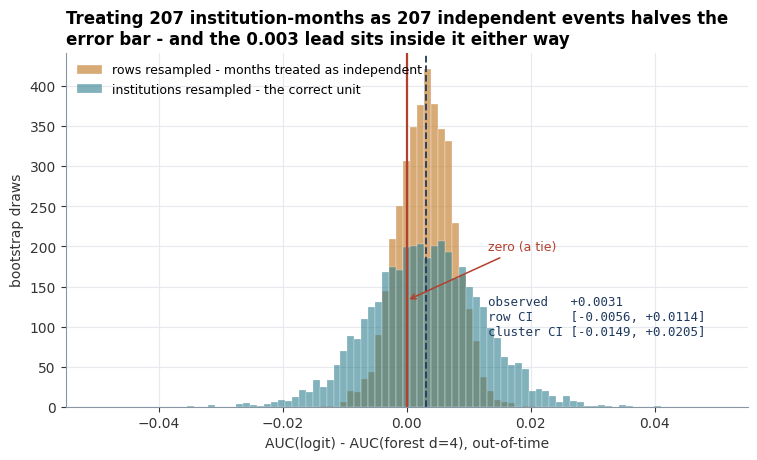

In [20]:
draws = boot_draws['Logit - Forest d=4']
observed = float(bootstrap.loc['Logit - Forest d=4', 'dAUC'])
row_lo = float(bootstrap.loc['Logit - Forest d=4', 'row_ci_low'])
row_hi = float(bootstrap.loc['Logit - Forest d=4', 'row_ci_high'])
clu_lo = float(bootstrap.loc['Logit - Forest d=4', 'cluster_ci_low'])
clu_hi = float(bootstrap.loc['Logit - Forest d=4', 'cluster_ci_high'])

fig, ax = plt.subplots(figsize=(8.8, 4.6))
bins = np.linspace(-0.05, 0.05, 90)
ax.hist(draws['row'], bins=bins, color=AMBER, alpha=0.70, edgecolor='white', linewidth=0.3,
        label='rows resampled - months treated as independent')
ax.hist(draws['cluster'], bins=bins, color=TEAL, alpha=0.60, edgecolor='white', linewidth=0.3,
        label='institutions resampled - the correct unit')
top = ax.get_ylim()[1]
ax.axvline(0, color=RED, lw=1.6)
ax.axvline(observed, color=NAVY, lw=1.3, ls='--')
ax.set_xlabel('AUC(logit) - AUC(forest d=4), out-of-time')
ax.set_ylabel('bootstrap draws')
ax.set_title('Treating 207 institution-months as 207 independent events halves the\n'
             'error bar - and the 0.003 lead sits inside it either way')
ax.legend(loc='upper left', fontsize=9)
ax.annotate('zero (a tie)', xy=(0, top * 0.30), xytext=(0.62, 0.44),
            textcoords='axes fraction', color=RED, fontsize=9,
            arrowprops=dict(arrowstyle='->', color=RED, lw=1.1))
ax.text(0.62, 0.20,
        f'observed   {observed:+.4f}\n'
        f'row CI     [{row_lo:+.4f}, {row_hi:+.4f}]\n'
        f'cluster CI [{clu_lo:+.4f}, {clu_hi:+.4f}]',
        transform=ax.transAxes, color=NAVY, fontsize=9, family='monospace')
finish(fig, 'bootstrap_dauc')

The amber distribution is what a naive row-level bootstrap would report, and the teal one is what
the data supports. Under clustering, a large share of resampled worlds hands the win to the forest,
and a model choice that flips with the draw of the sample isn't a choice made on discrimination.

### 9.2 Does the discrimination survive at institution level?

If the ranking only worked because one distressed institution contributes twelve nearly identical
rows, collapsing each institution to a single observation should destroy it. We take the mean
scorecard score per institution and call the institution bad if it was bad in any month.

In [21]:
collapsed = []
for tag, frame in (('train', train), ('oot', oot)):
    scored = frame.assign(score=finalists['Logit (WoE)'][0](frame))
    per_inst = scored.groupby('ID').agg(score=('score', 'mean'), bad=('target', 'max'),
                                        months=('DATA', 'size'))
    collapsed.append({'sample': tag,
                      'institutions': len(per_inst),
                      'bad institutions': int(per_inst['bad'].sum()),
                      'row-level AUC': results.loc['Logit (WoE)', f'{tag}_AUC'],
                      'institution-level AUC': roc_auc_score(1 - per_inst['bad'],
                                                             per_inst['score'])})

collapsed = pd.DataFrame(collapsed).set_index('sample')
print(collapsed.round(4).to_string())

        institutions  bad institutions  row-level AUC  institution-level AUC
sample                                                                      
train            167                36         0.8138                 0.8151
oot              157                23         0.8652                 0.8965


## 10. Pillar 1: the Point-in-Time macro overlay

Our exam answer led with the proposal to move the scorecard from Through-the-Cycle to
Point-in-Time by adding macroeconomic variables, so we test it here against the baseline
established above.

We pull three monthly series from the BCB SGS API: **4189 = SELIC** (accumulated in the month,
annualised), **433 = IPCA** and **24363 = IBC-Br**, then derive a 12-month inflation total and
12-month activity growth. Watch the trap here: series **432 is the *daily* SELIC**, and an unbounded
request for it returns an HTTP 406 error object rather than data. An earlier draft wrapped the fetch
in a bare `except`, which swallowed exactly that error and trained a model with no SELIC column while
the write-up went on crediting SELIC. So this fetch **raises** instead.

In [22]:
def fetch_sgs(code, name, start='01/01/2016'):
    """One monthly BCB SGS series as (DATA, value). Raises on any failure - never silent."""
    url = (f'https://api.bcb.gov.br/dados/serie/bcdata.sgs.{code}/dados'
           f'?formato=json&dataInicial={start}')
    response = requests.get(url, timeout=60)
    response.raise_for_status()
    payload = response.json()
    if not isinstance(payload, list) or not payload:
        raise RuntimeError(f'SGS {code} did not return a series: {payload!r:.200}')

    frame = pd.DataFrame(payload)
    stamp = pd.to_datetime(frame['data'], format='%d/%m/%Y')
    return pd.DataFrame({'DATA': stamp.dt.year * 100 + stamp.dt.month,
                         name: pd.to_numeric(frame['valor'].str.replace(',', '.'), errors='raise')})


macro = (fetch_sgs(4189, 'SELIC')
         .merge(fetch_sgs(433, 'IPCA'), on='DATA')
         .merge(fetch_sgs(24363, 'IBC'), on='DATA')
         .sort_values('DATA')
         .reset_index(drop=True))
macro['IPCA_12m'] = macro['IPCA'].rolling(12).sum()
macro['IBC_yoy'] = macro['IBC'].pct_change(12) * 100

MACRO = ['SELIC', 'IPCA_12m', 'IBC_yoy']
print(f'SGS series fetched: {macro["DATA"].min()} to {macro["DATA"].max()}, {len(macro)} months')

panel = lab.merge(macro[['DATA'] + MACRO], on='DATA', how='left')
print(f'macro coverage on the modelling frame: {panel[MACRO].notna().all(axis=1).mean():.1%}')

train_m = panel[panel['sample'] == 'train']
oot_m = panel[panel['sample'] == 'oot']
mr_m = panel[panel['sample'] == 'mr']
assert (oot_m['ID'].to_numpy() == id_oot).all()      # same rows, same order as section 9

print(f'oot SELIC: {oot_m["SELIC"].nunique()} distinct values, '
      f'{oot_m["SELIC"].min():.2f}-{oot_m["SELIC"].max():.2f} '
      f'(train {train_m["SELIC"].min():.2f}-{train_m["SELIC"].max():.2f})')

SGS series fetched: 201601 to 202606, 126 months
macro coverage on the modelling frame: 100.0%
oot SELIC: 6 distinct values, 11.87-13.65 (train 1.90-13.65)


Coverage is 100%, so no row is lost. But look at the last line: the out-of-time window spans twelve
months and contains only **six distinct SELIC values**, all between 11.87 and 13.65, against a train
range of 1.90 to 13.65. There's very little macro variation in `oot` to identify a macro effect
from.

In [23]:
def macro_row(name, scorer):
    return {'model': name,
            'train_AUC': roc_auc_score(train_m['y_adj'], scorer(train_m)),
            'oot_AUC': roc_auc_score(oot_m['y_adj'], scorer(oot_m)),
            'mr_AUC': roc_auc_score(mr_m['y_adj'], scorer(mr_m))}


logit_macro = sm.Logit(train_m['y_adj'], sm.add_constant(train_m[FEATURES + MACRO])).fit(disp=0)
forest_macro = RandomForestClassifier(n_estimators=500, max_depth=4, min_samples_leaf=20,
                                      class_weight='balanced', random_state=SEED, n_jobs=-1)
forest_macro.fit(train_m[FEATURES + MACRO], train_m['y_adj'])

macro_results = pd.DataFrame([
    macro_row('Logit WoE (baseline)',
              lambda d: logit.predict(sm.add_constant(d[FEATURES], has_constant='add'))),
    macro_row('Logit WoE + macro',
              lambda d: logit_macro.predict(sm.add_constant(d[FEATURES + MACRO],
                                                            has_constant='add'))),
    macro_row('Forest WoE d=4', lambda d: forests[4].predict_proba(d[FEATURES])[:, 1]),
    macro_row('Forest WoE + macro d=4',
              lambda d: forest_macro.predict_proba(d[FEATURES + MACRO])[:, 1]),
]).set_index('model')
print(macro_results.round(4).to_string())

macro_importance = pd.Series(forest_macro.feature_importances_, index=FEATURES + MACRO)
print()
print('forest importance with macro added:')
print(macro_importance.round(3).to_string())
print(f'macro share of total importance: {macro_importance[MACRO].sum():.1%}')

                        train_AUC  oot_AUC  mr_AUC
model                                             
Logit WoE (baseline)       0.8138   0.8652  0.6850
Logit WoE + macro          0.8137   0.8646  0.6882
Forest WoE d=4             0.8339   0.8620  0.6902
Forest WoE + macro d=4     0.8361   0.8688  0.6853

forest importance with macro added:
A01_woe     0.222
M01_woe     0.123
E01_woe     0.503
L01_woe     0.092
SELIC       0.027
IPCA_12m    0.021
IBC_yoy     0.013
macro share of total importance: 6.1%


Adding macro does nothing for the logit (0.8652 to 0.8646) and appears to help the forest: 0.8620 to
**0.8688**, a gain of +0.0067. Taken at face value that's our Pillar 1 confirmed. But the three macro
variables carry only **6.1%** of the forest's importance, which is the first sign the gain may not be
about macroeconomics at all.

### 10.1 Does the macro gain survive a clustered test?

In [24]:
s_forest_macro = forest_macro.predict_proba(oot_m[FEATURES + MACRO])[:, 1]

macro_boot = []
for name, a, b in [('Logit - Forest+macro', s_logit, s_forest_macro),
                   ('Forest - Forest+macro', s_forest, s_forest_macro)]:
    _, row_lo, row_hi, row_p, _ = paired_bootstrap(y_oot, a, b)
    observed, lo, hi, p_value, _ = paired_bootstrap(y_oot, a, b, groups=id_oot)
    macro_boot.append({'comparison': name, 'dAUC': observed,
                       'row_ci_low': row_lo, 'row_ci_high': row_hi, 'row_p': row_p,
                       'cluster_ci_low': lo, 'cluster_ci_high': hi, 'cluster_p': p_value,
                       'verdict': 'significant' if p_value < 0.05 else 'not significant'})

macro_boot = pd.DataFrame(macro_boot).set_index('comparison')
print(macro_boot.round(4).to_string())

                         dAUC  row_ci_low  row_ci_high   row_p  cluster_ci_low  cluster_ci_high  cluster_p          verdict
comparison                                                                                                                 
Logit - Forest+macro  -0.0036     -0.0100       0.0028  0.2705         -0.0156           0.0081     0.5570  not significant
Forest - Forest+macro -0.0067     -0.0113      -0.0020  0.0035         -0.0159           0.0024     0.1515  not significant


This is the clearest demonstration in the notebook of why clustering matters. Treat months as
independent and the macro gain is significant (p = 0.004). Resample **institutions** and the same
-0.0067 comes with a 95% interval of [-0.016, +0.002] and **p = 0.15, not significant**. The one
result in the whole comparison that looked statistically real doesn't survive the correct unit of
observation.

### 10.2 The placebo test

Macro variables are constant within a reporting month, so a forest handed three extra time-varying
columns can improve simply by partitioning the calendar, with no economics involved. We test that
directly: keep the macro *values*, re-date them to randomly permuted months, refit, and measure the
gain 50 times. If the real gain is macroeconomics, the placebo gains should sit near zero.

In [25]:
MONTHS = np.sort(panel['DATA'].unique())
macro_by_month = macro.set_index('DATA').loc[MONTHS, MACRO]
real_gain = roc_auc_score(y_oot, s_forest_macro) - roc_auc_score(y_oot, s_forest)

rng = np.random.default_rng(7)
placebo_gains = []
for draw in range(50):
    shuffled = pd.DataFrame(macro_by_month.to_numpy()[rng.permutation(len(MONTHS))],
                            index=MONTHS, columns=MACRO)
    fit_X = train_m[FEATURES].copy()
    oot_X = oot_m[FEATURES].copy()
    for column in MACRO:
        fit_X[column] = train_m['DATA'].map(shuffled[column])
        oot_X[column] = oot_m['DATA'].map(shuffled[column])

    placebo = RandomForestClassifier(n_estimators=500, max_depth=4, min_samples_leaf=20,
                                     class_weight='balanced', random_state=SEED, n_jobs=-1)
    placebo.fit(fit_X, train_m['y_adj'])
    placebo_gains.append(roc_auc_score(y_oot, placebo.predict_proba(oot_X)[:, 1])
                         - roc_auc_score(y_oot, s_forest))

placebo_gains = np.asarray(placebo_gains)
print(f'real gain from correctly dated macro : {real_gain:+.4f}')
print(f'placebo gains over {len(placebo_gains)} draws        : mean {placebo_gains.mean():+.4f}, '
      f'sd {placebo_gains.std(ddof=1):.4f}, '
      f'range [{placebo_gains.min():+.4f}, {placebo_gains.max():+.4f}]')
print(f'placebo draws reaching the real gain : {int((placebo_gains >= real_gain).sum())} '
      f'of {len(placebo_gains)}')
print(f'share of the gain that is period structure: {placebo_gains.mean() / real_gain:.0%}')

real gain from correctly dated macro : +0.0067
placebo gains over 50 draws        : mean +0.0042, sd 0.0008, range [+0.0023, +0.0058]
placebo draws reaching the real gain : 0 of 50
share of the gain that is period structure: 63%


saved 04_placebo.png


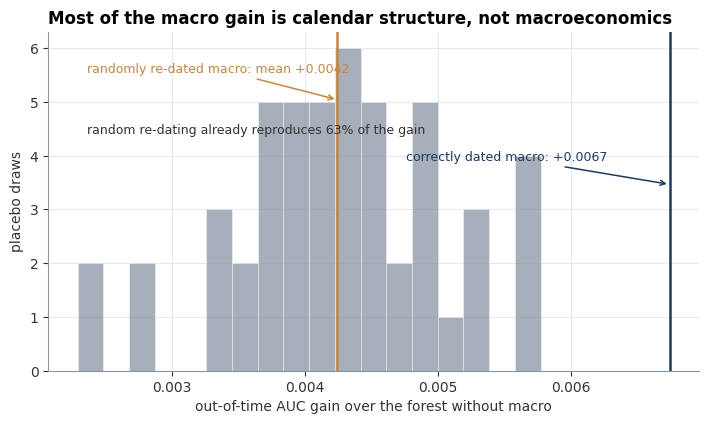

In [26]:
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.hist(placebo_gains, bins=18, color=GREY, alpha=0.75, edgecolor='white', linewidth=0.4)
top = ax.get_ylim()[1]
ax.axvline(placebo_gains.mean(), color=AMBER, lw=1.8)
ax.axvline(real_gain, color=NAVY, lw=1.8)
ax.set_xlabel('out-of-time AUC gain over the forest without macro')
ax.set_ylabel('placebo draws')
ax.set_title('Most of the macro gain is calendar structure, not macroeconomics')
ax.annotate(f'randomly re-dated macro: mean {placebo_gains.mean():+.4f}',
            xy=(placebo_gains.mean(), top * 0.80), xytext=(0.06, 0.88),
            textcoords='axes fraction', color=AMBER, fontsize=9,
            arrowprops=dict(arrowstyle='->', color=AMBER, lw=1.1))
ax.annotate(f'correctly dated macro: {real_gain:+.4f}',
            xy=(real_gain, top * 0.55), xytext=(0.55, 0.62),
            textcoords='axes fraction', color=NAVY, fontsize=9,
            arrowprops=dict(arrowstyle='->', color=NAVY, lw=1.1))
ax.text(0.06, 0.70,
        f'random re-dating already reproduces {placebo_gains.mean() / real_gain:.0%} of the gain',
        transform=ax.transAxes, color='#333333', fontsize=9)
finish(fig, 'placebo')

Re-dated macro still buys a mean gain of **+0.0042**, roughly **63%** of the real +0.0067, so most
of what looked like a Point-in-Time effect is the forest exploiting *any* time-varying partition of
the panel. The real series does clear every one of the 50 placebo draws, so a genuine residual of
about **+0.0025 AUC** remains, but that's far too small to displace the baseline, and section 10.1 has
already shown that even the full +0.0067 isn't significant once institutions are resampled.

**Pillar 1 is withdrawn on this dataset**, and it fails on two independent grounds: not significant
under clustering, and ~63% calendar artefact under the placebo. Two separate tests agreeing is a
stronger result than either alone. One refinement we owe ourselves: we specified macro as three
*additive* columns, while our own Pillar 3 argument was about an **interaction**, a rate spike hurting
a weakly-liquid institution more than a strongly-earning one. So we tested the weaker form of our own
hypothesis, and an interaction specification on a panel spanning more than one rate cycle is the
natural next test.

## 11. Explaining the forest with SHAP

Session 7 slide 26 lists "less interpretability" as the forest's main cost, and slide 29 answers it:
regulators accept machine-learning models "when paired with rigorous explainability", with SHAP as
the standard tool. We test the objection rather than assuming it. Can the forest be explained?

mean |SHAP| (impact on P(good)), oot sample of 800 rows:
E01_woe    0.1618
A01_woe    0.0696
M01_woe    0.0457
L01_woe    0.0420
saved 04_shap_beeswarm.png


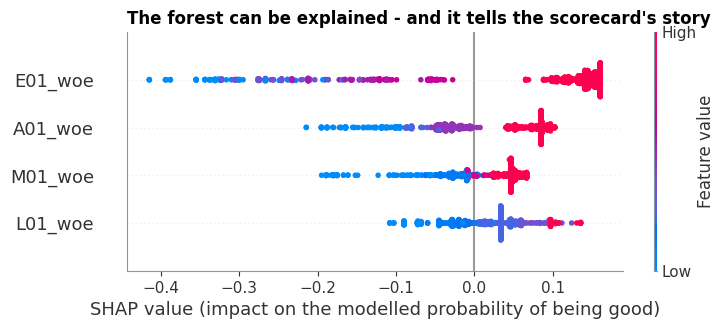

In [27]:
explain_sample = oot[FEATURES].sample(n=800, random_state=SEED)
explainer = shap.TreeExplainer(forests[4])
shap_values = explainer(explain_sample, check_additivity=False)[..., 1]

mean_abs = (pd.Series(np.abs(shap_values.values).mean(axis=0), index=FEATURES)
              .sort_values(ascending=False))
print('mean |SHAP| (impact on P(good)), oot sample of 800 rows:')
print(mean_abs.round(4).to_string())

fig = plt.figure(figsize=(7.6, 4.2))
shap.plots.beeswarm(shap_values, show=False, color_bar=True)
ax = plt.gca()
ax.set_title('The forest can be explained - and it tells the scorecard\'s story')
ax.set_xlabel('SHAP value (impact on the modelled probability of being good)')
ax.grid(False)
finish(fig, 'shap_beeswarm')

The beeswarm is readable and monotone: high WoE values (healthy bins, red) push the modelled
probability towards "good" and low values (blue) push it towards "bad", with no sign reversals. A weak
earnings bin moves a prediction by up to 0.4 in probability on its own. `E01_woe` dominates, exactly
as in the logit's coefficients and the tree's root split.

Two conclusions follow. First, the governance objection to the forest is answerable. It *can* be
explained at both portfolio and single-institution level, which is why we keep it as a viable
challenger. Second, an explanation that reproduces the scorecard's story is an explanation the
scorecard already gives directly, in four coefficients, without a post-hoc tool.

## 12. Verdict

Session 7 slide 28 scores the two approaches on five dimensions. We fill it in for *this* dataset
and *these* results rather than in general.

In [28]:
grid = pd.DataFrame([
    {'dimension': 'Interpretability',
     'parametric logit': 'four signed coefficients, odds ratios, marginal effects',
     'non-parametric forest': 'needs SHAP post-hoc; single trees are unstable',
     'winner': 'logit'},
    {'dimension': 'Accuracy on non-linear patterns',
     'parametric logit': 'oot AUC 0.8652',
     'non-parametric forest': 'oot AUC 0.8620 (dAUC +0.0031, cluster p = 0.73)',
     'winner': 'tie'},
    {'dimension': 'Overfitting risk',
     'parametric logit': 'train 0.8138 vs oot 0.8652 - no gap',
     'non-parametric forest': 'train up to 0.9914 vs oot 0.8341 on raw ratios',
     'winner': 'logit'},
    {'dimension': 'Governance / audit fit',
     'parametric logit': 'standard scorecard, WoE bins auditable per variable',
     'non-parametric forest': 'acceptable with explainability, heavier to document',
     'winner': 'logit'},
    {'dimension': 'Typical use case',
     'parametric logit': 'regulatory capital, pricing, rating scale',
     'non-parametric forest': 'challenger, early warning, variable discovery',
     'winner': 'both (different roles)'},
]).set_index('dimension')

print(grid.to_string())

                                                                        parametric logit                                non-parametric forest                  winner
dimension                                                                                                                                                            
Interpretability                 four signed coefficients, odds ratios, marginal effects       needs SHAP post-hoc; single trees are unstable                   logit
Accuracy on non-linear patterns                                           oot AUC 0.8652      oot AUC 0.8620 (dAUC +0.0031, cluster p = 0.73)                     tie
Overfitting risk                                     train 0.8138 vs oot 0.8652 - no gap       train up to 0.9914 vs oot 0.8341 on raw ratios                   logit
Governance / audit fit               standard scorecard, WoE bins auditable per variable  acceptable with explainability, heavier to document                   logit
Typi

**Decision: the parametric WoE logistic scorecard is our primary model; the depth-4 random
forest is retained as a challenger and early-warning overlay.**

Not because the forest failed, but because it **tied**. Discrimination is statistically
indistinguishable once the bootstrap is clustered by institution (p = 0.73), and once accuracy is a
tie the remaining four dimensions all favour the scorecard: it's directly interpretable, it shows no
train-to-out-of-time decay, it's the form supervisors and rating committees already know how to audit,
and it produces the monotone score a rating scale can be cut on.

**Why the tie happens, as a diagnosis rather than an excuse.** Optimal WoE binning already fits a
monotone step function to each variable before the model sees it, so the main non-linearity a tree
could discover has been applied in advance. With four pre-binned inputs and 680 training events
there's very little interaction structure left to find. That also predicts when the conclusion would
flip: more variables, or more events, would give the forest something to work with. Section 8 supports
that reading, since flexible learners handed the raw, unbinned ratios found training fit and nothing
transportable.

**Why the model is sufficient**: out-of-time AUC 0.8652, Gini 0.7304, KS 0.584 on a harder year than
it was trained on, with four significant, correctly-signed, economically readable coefficients. That's
above the ~0.84 benchmark Session 7 slide 29 quotes for gradient boosting on standard credit
datasets.

### What this means for the three pillars we proposed

- **Pillar 2 (prudential conglomerate as the unit of analysis): adopted.** It's built into the panel
  loaded above, and it's what made the rest measurable. It's the reason `oot` carries 207 bad
  institution-months rather than 31.
- **Pillar 3 (random forests): adopted, with our conclusion reversed.** Like for like, the forest ties
  with the scorecard rather than beating it, so it becomes the **challenger**, not the primary model.
- **Pillar 1 (Point-in-Time macro overlay): withdrawn on this dataset**, on two independent grounds.
  Adding SELIC, IPCA and IBC-Br moved oot AUC by +0.0067, but (i) that gain is **not significant** once
  the bootstrap is clustered by institution (p = 0.15), and (ii) a placebo that re-dates the same macro
  values to permuted months recovers a mean +0.0042 of it, so roughly **63% is calendar structure
  rather than macroeconomics**. Macro carries 6.1% of forest importance. We also tested the weaker form
  of our own hypothesis: Pillar 1 specified three *additive* macro columns, while Pillar 3's argument
  was about an **interaction** between the macro state and institution-level liquidity. That, on a
  panel spanning more than one rate cycle, is the next test.

The full text of the proposal and the measured outcome of each pillar are in
[`PROPOSAL.md`](PROPOSAL.md).

### Limitations

Stated plainly, because a model is only defensible with its boundaries attached.

- Only 3 institutions / 23 rows carry the explicit default flag, so the target is dominated by the
  regulatory capital-breach rule. This is a **capital-distress model, not a liquidation model**, and
  we describe it that way.
- `mr` AUC falls to about 0.68 for *every* model because CMN Resolution 4.966 removed the source
  accounts for `A01` and `M01` from 2025-01. That's a data-coverage failure upstream rather than a
  model failure, but it does mean the model can't currently be run on the newest regime without
  rebuilding those two ratios.
- 207 out-of-time bad institution-months from only 23 conglomerates. Once the bootstrap respects that
  dependence, AUC differences below roughly 0.02 aren't resolvable, which is exactly why we report
  every comparison here as a tie.
- Rows are institution-months, so they aren't independent observations. We handle that by resampling
  institutions rather than rows, and the row-level intervals are reported only to show what ignoring
  the dependence would have claimed.
- The macro overlay is identified off very little variation: `oot` spans twelve months but holds only
  six distinct SELIC values, so a null there is weak evidence about macro effects in general.
- Both the target and the features derive from self-reported supervisory filings.
- Rating-scale calibration and PSI monitoring belong to Session 8, which hasn't been taught yet, so we
  use KS and Gini here as descriptive discrimination measures in anticipation of it.

## 13. Outputs

`df_scores.parquet` carries one row per labelled observation with the three finalist scores, for the
monitoring notebook to consume. `model_comparison.xlsx` carries the metric, coefficient, bootstrap
and decision tables for the report.

In [29]:
scores = lab[['ID', 'DATA', 'sample', 'target', 'y_adj']].copy()
for column, (scorer, _colour) in (('score_logit', finalists['Logit (WoE)']),
                                  ('score_tree', finalists['Tree entropy d=3']),
                                  ('score_forest', finalists['Forest d=4'])):
    scores[column] = scorer(lab)

assert scores[['score_logit', 'score_tree', 'score_forest']].notna().all().all()
scores.to_parquet(dir_output / 'df_scores.parquet')
print(f'saved df_scores.parquet - {scores.shape[0]:,} rows x {scores.shape[1]} columns')
print(scores.head().round(4).to_string(index=False))

with pd.ExcelWriter(dir_output / 'model_comparison.xlsx', engine='openpyxl') as writer:
    results.round(6).to_excel(writer, sheet_name='metrics')
    coef_table.to_excel(writer, sheet_name='logit_coefficients')
    bootstrap.round(6).to_excel(writer, sheet_name='bootstrap')
    macro_results.round(6).to_excel(writer, sheet_name='macro_metrics')
    macro_boot.round(6).to_excel(writer, sheet_name='macro_bootstrap')
    pd.DataFrame({'placebo_gain': placebo_gains}).to_excel(writer, sheet_name='placebo')
    grid.to_excel(writer, sheet_name='decision_grid')
print('saved model_comparison.xlsx - sheets: metrics, logit_coefficients, bootstrap,',
      'macro_metrics, macro_bootstrap, placebo, decision_grid')

print('\nfigures written:')
for path in sorted(dir_figures.glob('04_*.png')):
    print(f'  {path.name}')

saved df_scores.parquet - 13,666 rows x 8 columns
      ID   DATA sample  target  y_adj  score_logit  score_tree  score_forest
C0080329 201703  train       0      1       0.9765      0.8485        0.8262
C0080288 201703  train       0      1       0.9765      0.8485        0.8262
C0080446 201703  train       0      1       0.7685      0.3704        0.3053
C0080707 201703  train       0      1       0.7714      0.3704        0.3283
C0080738 201703  train       0      1       0.9765      0.8485        0.8262
saved model_comparison.xlsx - sheets: metrics, logit_coefficients, bootstrap, macro_metrics, macro_bootstrap, placebo, decision_grid

figures written:
  04_bootstrap_dauc.png
  04_overfitting.png
  04_placebo.png
  04_roc_oot.png
  04_shap_beeswarm.png
  04_tree_depth3.png


Both files are written. Notebook 05 reads `df_scores.parquet` to build the rating scale and the
monitoring report on the primary model, keeping the forest score alongside it as the challenger.